<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/Student_Mental_Analysis%5BEDA_%2B_ML%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

In [73]:
data = pd.read_csv('/content/Student Mental health.csv') # Changed to a sample CSV file
display(data.head()) # Use display() for better output in Colab

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [75]:
data = data[data['Age'].notna()]
data.shape

(100, 11)

In [76]:
data.head(1)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No


In [77]:
data.columns = ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Treatment']
data.head(1)

,Timestamp,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No


In [78]:
data.columns = ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Treatment']
display(data.head())

,Timestamp,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [79]:
#Formatting the Year column
data['Year'].unique()

array(['year 1', 'year 2', 'Year 1', 'year 3', 'year 4', 'Year 2',
       'Year 3'], dtype=object)

In [80]:
def Clean(Text):
  Text = Text[-1]
  Text = int(Text)
  return Text
data["Year"] = data["Year"].apply(Clean)
print("First three values of Year after cleaning text:")
print(data["Year"][:3], "\n")
print(f"Year column dtype: {data['Year'].dtype}")

First three values of Year after cleaning text:
0    1
1    2
2    1
Name: Year, dtype: int64 

Year column dtype: int64


In [81]:
# The 'Year' column has already been cleaned and converted to int64.
# No further cleaning with string manipulation is needed.

print(f"Year column is already of type: {data['Year'].dtype}")

Year column is already of type: int64


In [82]:
data['CGPA'].unique()

array(['3.00 - 3.49', '3.50 - 4.00', '3.50 - 4.00 ', '2.50 - 2.99',
       '2.00 - 2.49', '0 - 1.99'], dtype=object)

In [83]:
def remove_space(string):
  string = string.strip()
  return string
data['CGPA'] = data['CGPA'].apply(remove_space)
print("First three values of CGPA after cleaning text:")
print(data["CGPA"][:3], "\n")
data['CGPA'].unique()

First three values of CGPA after cleaning text:
0    3.00 - 3.49
1    3.00 - 3.49
2    3.00 - 3.49
Name: CGPA, dtype: object 



array(['3.00 - 3.49', '3.50 - 4.00', '2.50 - 2.99', '2.00 - 2.49',
       '0 - 1.99'], dtype=object)

In [84]:
len(data['Course'].unique())

49

In [85]:
#Let's replace redundant course name with the standard course name
data['Course'].replace({'engin': 'Engineering' , 'Engine':'Engineering' , 'Islamic education':'Islamic Education' , 'Pendidikan islam':'Pendidikan Islam' , 'BIT':'IT', 'psychology':'Psychology', 'koe': 'Koe', 'Kirkhs': 'Irkhs', 'KIRKHS': 'Irkhs', 'Benl': 'BENL', 'Fiqh fatwa ': 'Fiqh', 'Laws': 'Law'} , inplace = True)
len(data['Course'].unique())

37

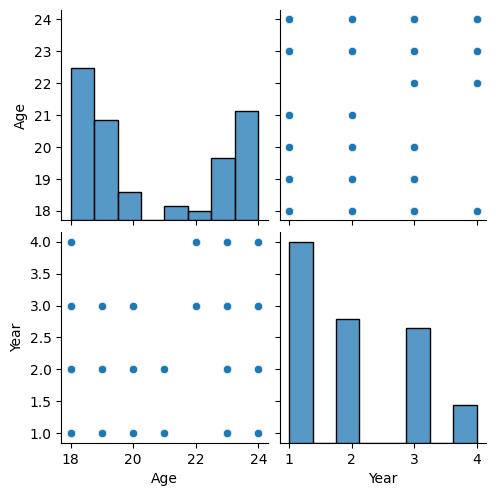

In [86]:
sns.pairplot(data)

[Text(0, 0, 'Engineering'),
 Text(1, 0, 'IT'),
 Text(2, 0, 'BCS'),
 Text(3, 0, 'Irkhs'),
 Text(4, 0, 'Psychology'),
 Text(5, 0, 'Banking Studies'),
 Text(6, 0, 'ALA'),
 Text(7, 0, 'BENL'),
 Text(8, 0, 'CTS'),
 Text(9, 0, 'Econs'),
 Text(10, 0, 'Malcom'),
 Text(11, 0, 'Biomedical science'),
 Text(12, 0, 'KOE'),
 Text(13, 0, 'Radiography'),
 Text(14, 0, 'Islamic Education')]

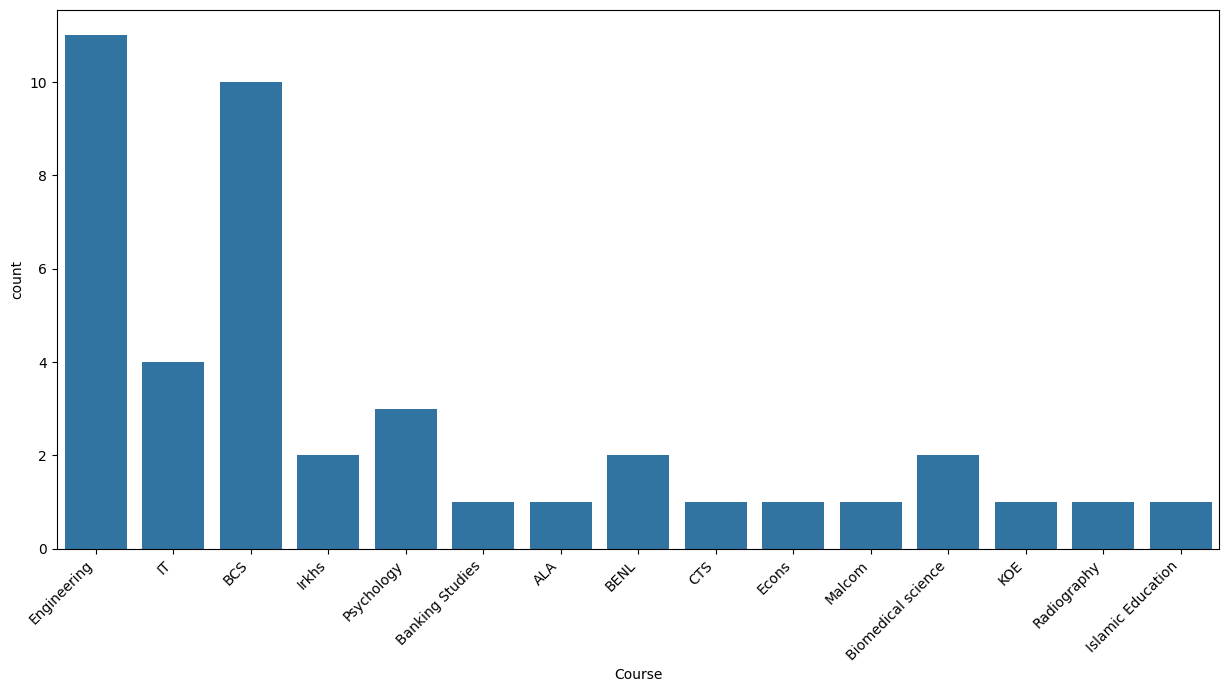

In [87]:
plt.figure(figsize=(15, 7))
chart = sns.countplot(x= 'Course', data = data[data['Year'] == 1])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')

[Text(0, 0, 'Islamic Education'),
 Text(1, 0, 'Engineering'),
 Text(2, 0, 'Pendidikan Islam'),
 Text(3, 0, 'Human Resources'),
 Text(4, 0, 'KENMS'),
 Text(5, 0, 'IT'),
 Text(6, 0, 'Marine science'),
 Text(7, 0, 'KOE'),
 Text(8, 0, 'Business Administration'),
 Text(9, 0, 'BCS'),
 Text(10, 0, 'Usuluddin '),
 Text(11, 0, 'TAASL'),
 Text(12, 0, 'Human Sciences '),
 Text(13, 0, 'Communication '),
 Text(14, 0, 'Diploma Nursing'),
 Text(15, 0, 'Pendidikan Islam '),
 Text(16, 0, 'Koe'),
 Text(17, 0, 'Biomedical science')]

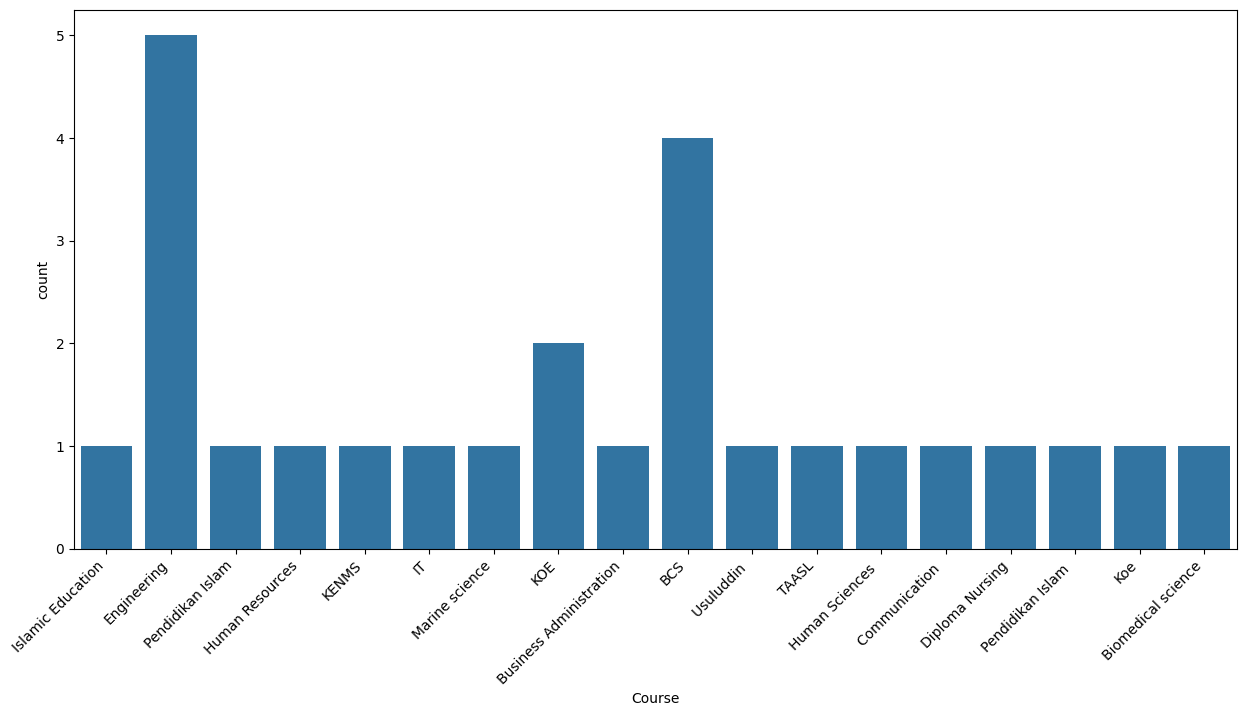

In [88]:
plt.figure(figsize=(15, 7))
chart = sns.countplot(x = 'Course', data = data[data['Year'] == 2])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')

[Text(0, 0, 'Law'),
 Text(1, 0, 'Engineering'),
 Text(2, 0, 'BCS'),
 Text(3, 0, 'Accounting '),
 Text(4, 0, 'IT'),
 Text(5, 0, 'Biomedical science'),
 Text(6, 0, 'Koe'),
 Text(7, 0, 'Irkhs'),
 Text(8, 0, 'BENL'),
 Text(9, 0, 'KOE'),
 Text(10, 0, 'MHSC'),
 Text(11, 0, 'Biotechnology'),
 Text(12, 0, 'Fiqh'),
 Text(13, 0, 'DIPLOMA TESL'),
 Text(14, 0, 'Nursing ')]

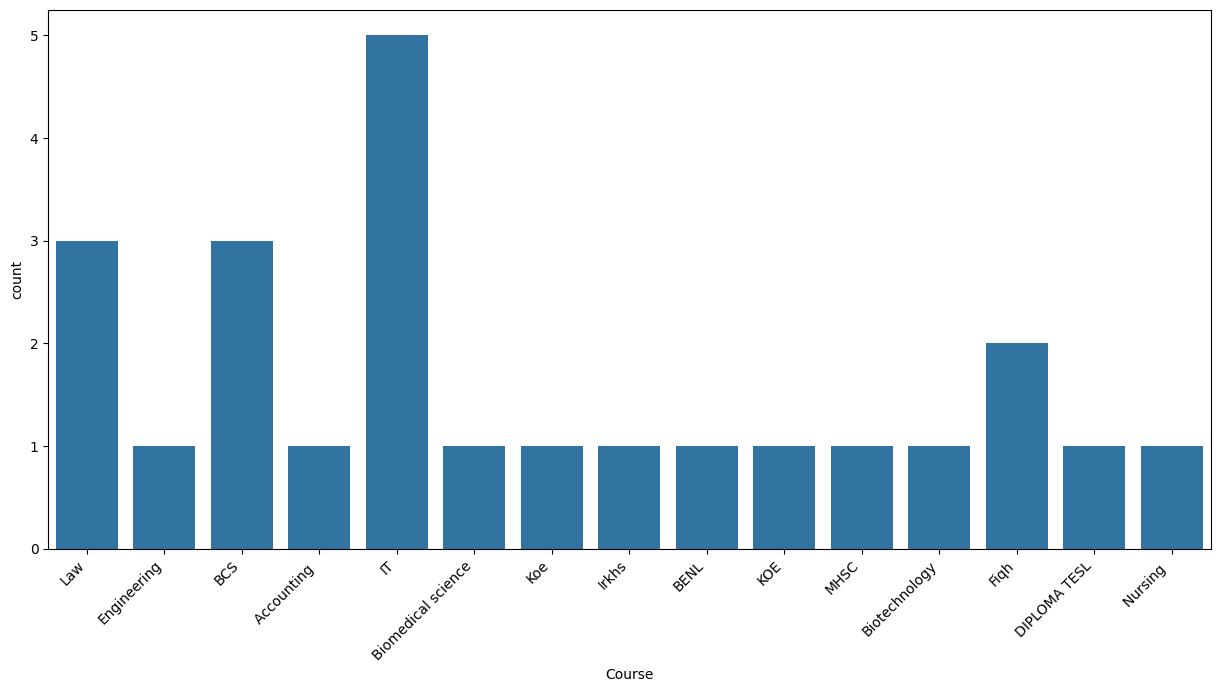

In [89]:
plt.figure(figsize=(15, 7))
chart = sns.countplot(x = 'Course', data = data[data['Year'] == 3])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')

[Text(0, 0, 'Mathemathics'),
 Text(1, 0, 'ENM'),
 Text(2, 0, 'BCS'),
 Text(3, 0, 'Engineering'),
 Text(4, 0, 'Kop'),
 Text(5, 0, 'Pendidikan Islam')]

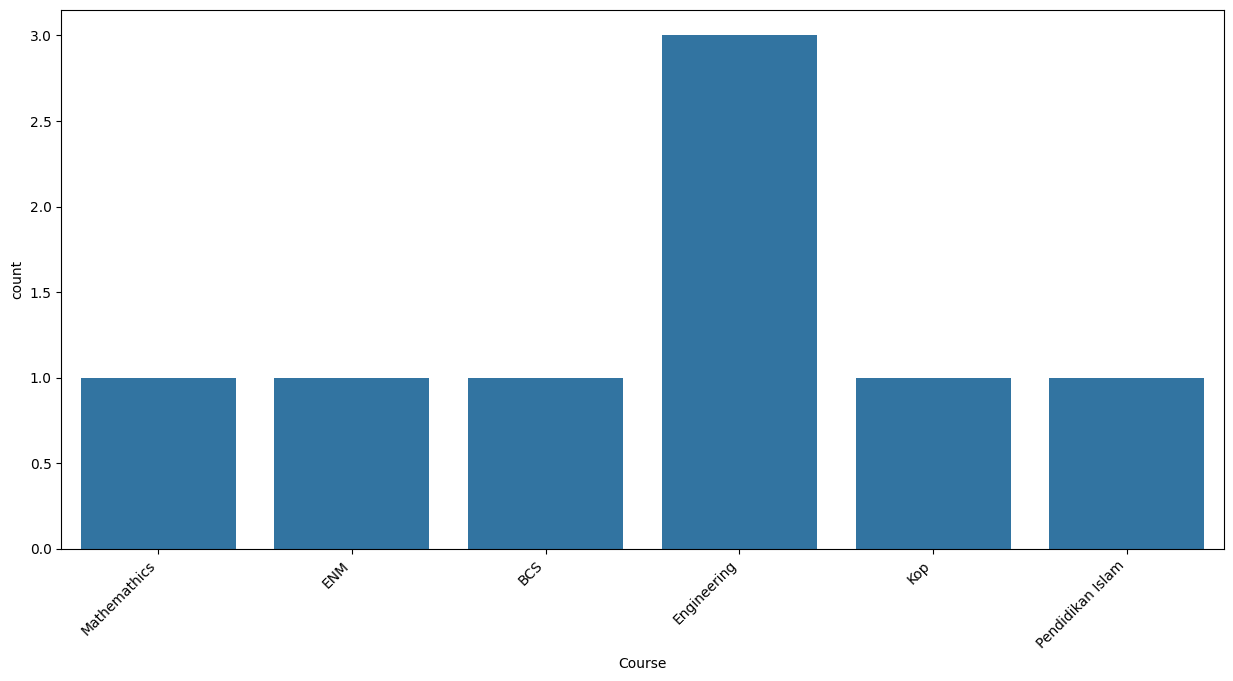

In [90]:
plt.figure(figsize=(15, 7))
chart = sns.countplot(x = 'Course', data = data[data['Year'] == 4])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')

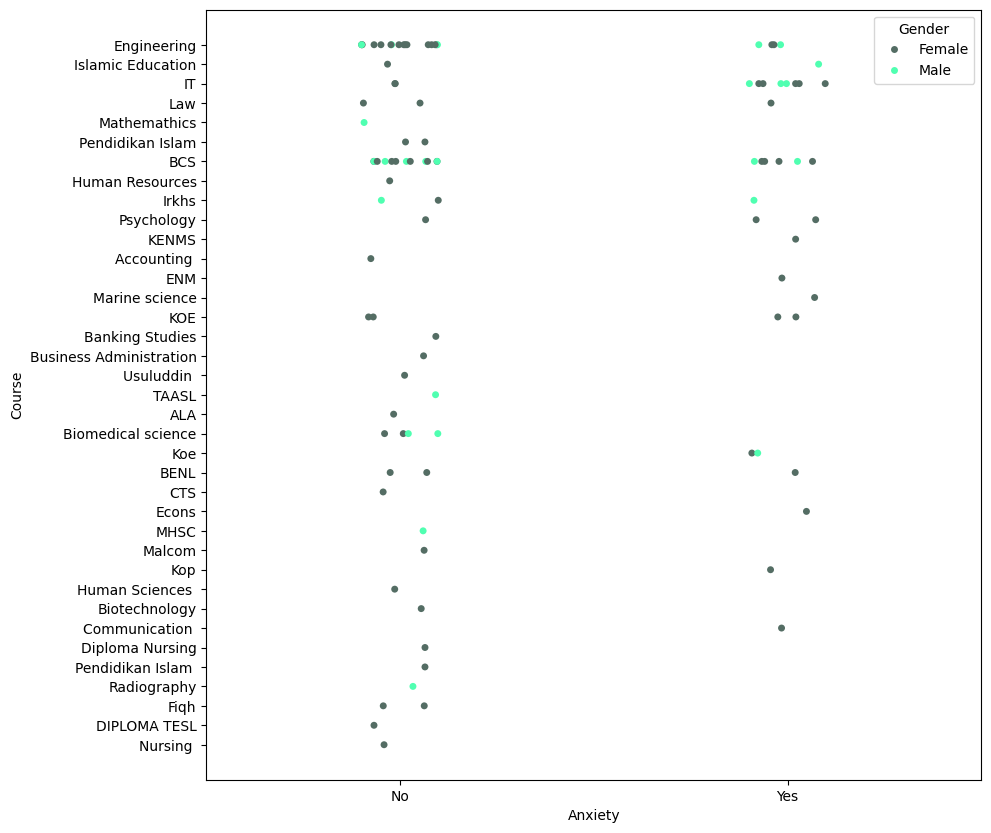

In [91]:
plt.figure(figsize=(10, 10))
sns.stripplot(x = 'Anxiety', y = 'Course', hue = 'Gender', data = data, palette = ['#546D64', '#50FFB1'])
plt.show()

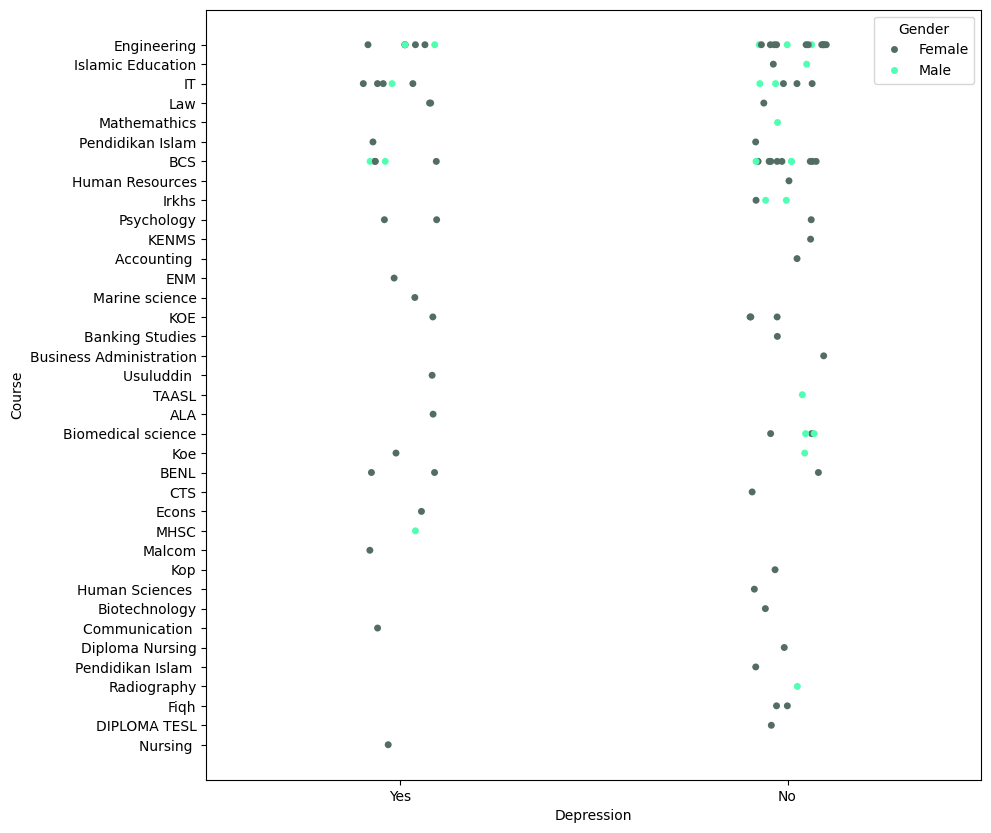

In [92]:
plt.figure(figsize=(10, 10))
sns.stripplot(x = 'Depression', y = 'Course', hue = 'Gender', data = data, palette = ['#546D64', '#50FFB1'])
plt.show()

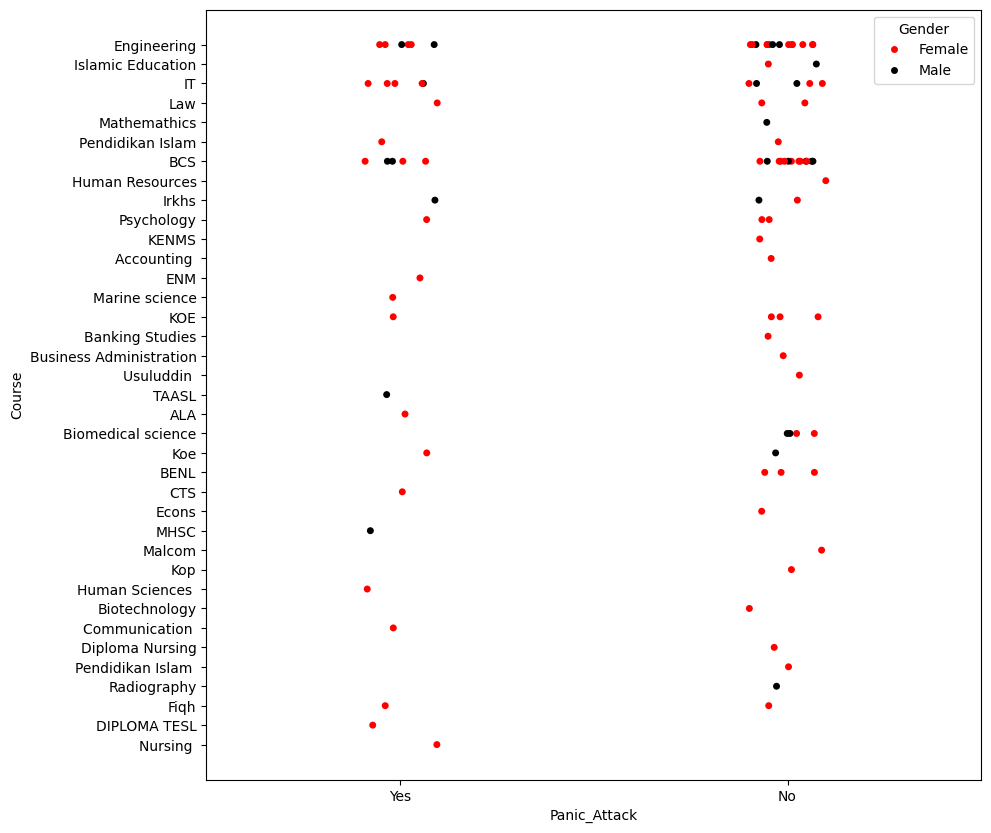

In [93]:
plt.figure(figsize=(10, 10))
sns.stripplot(x = 'Panic_Attack', y = 'Course', hue = 'Gender', data = data, palette = ['red', 'black'])
plt.show()

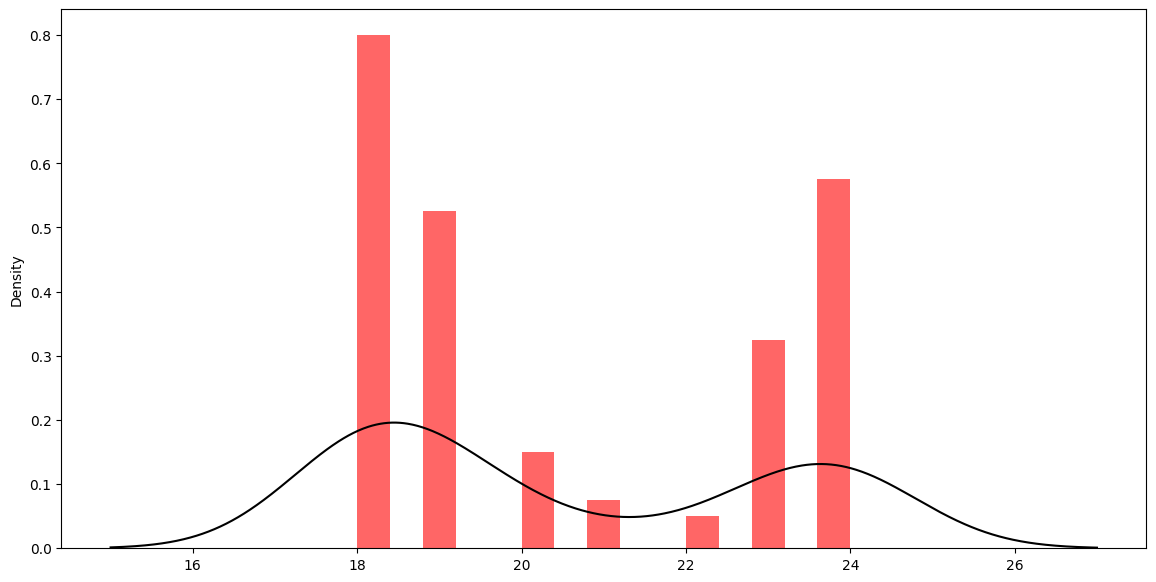

In [94]:
plt.figure(figsize=(14,7))
ax = data["Age"].hist(bins=15, density=True, stacked=True, color='red', alpha=0.6)
data["Age"].plot(kind='density', color='black')
plt.show()

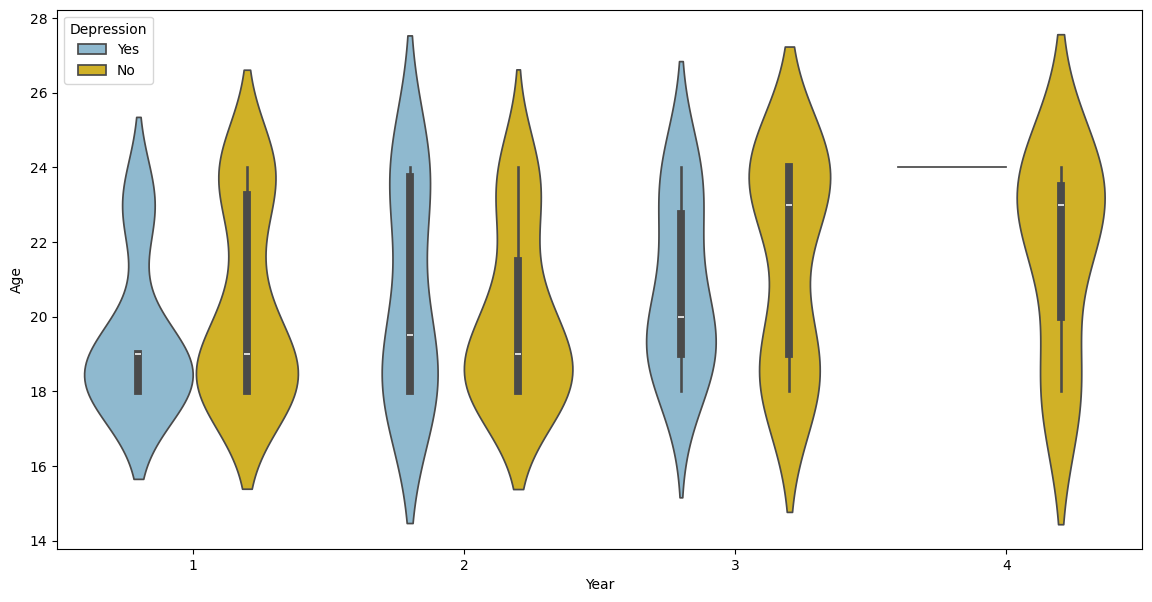

In [95]:
plt.figure(figsize=(14,7))
sns.violinplot(x = 'Year', y = 'Age', data = data,  hue = 'Depression', palette = ['#84BCDA', '#ECC30B'])
plt.show()

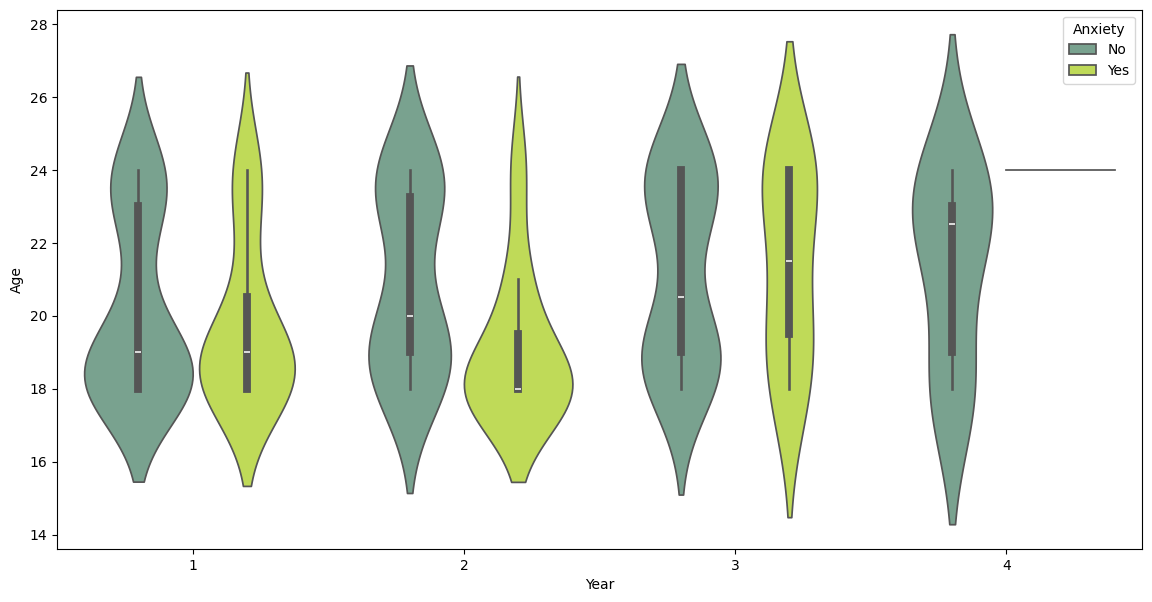

In [96]:
plt.figure(figsize=(14,7))
sns.violinplot(x = 'Year', y = 'Age', data = data,  hue = 'Anxiety', palette = ['#72A98F', '#CBEF43'])
plt.show()

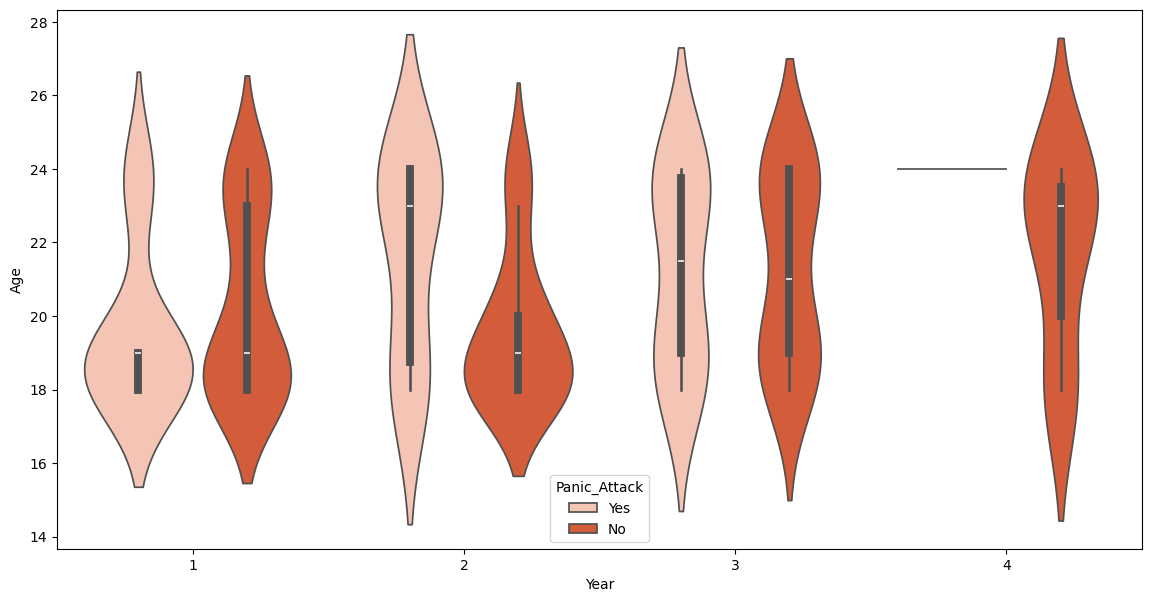

In [97]:
plt.figure(figsize=(14,7))
sns.violinplot(x = 'Year', y = 'Age', data = data,  hue = 'Panic_Attack', palette = ['#FEC0AA', '#EC4E20'])
plt.show()

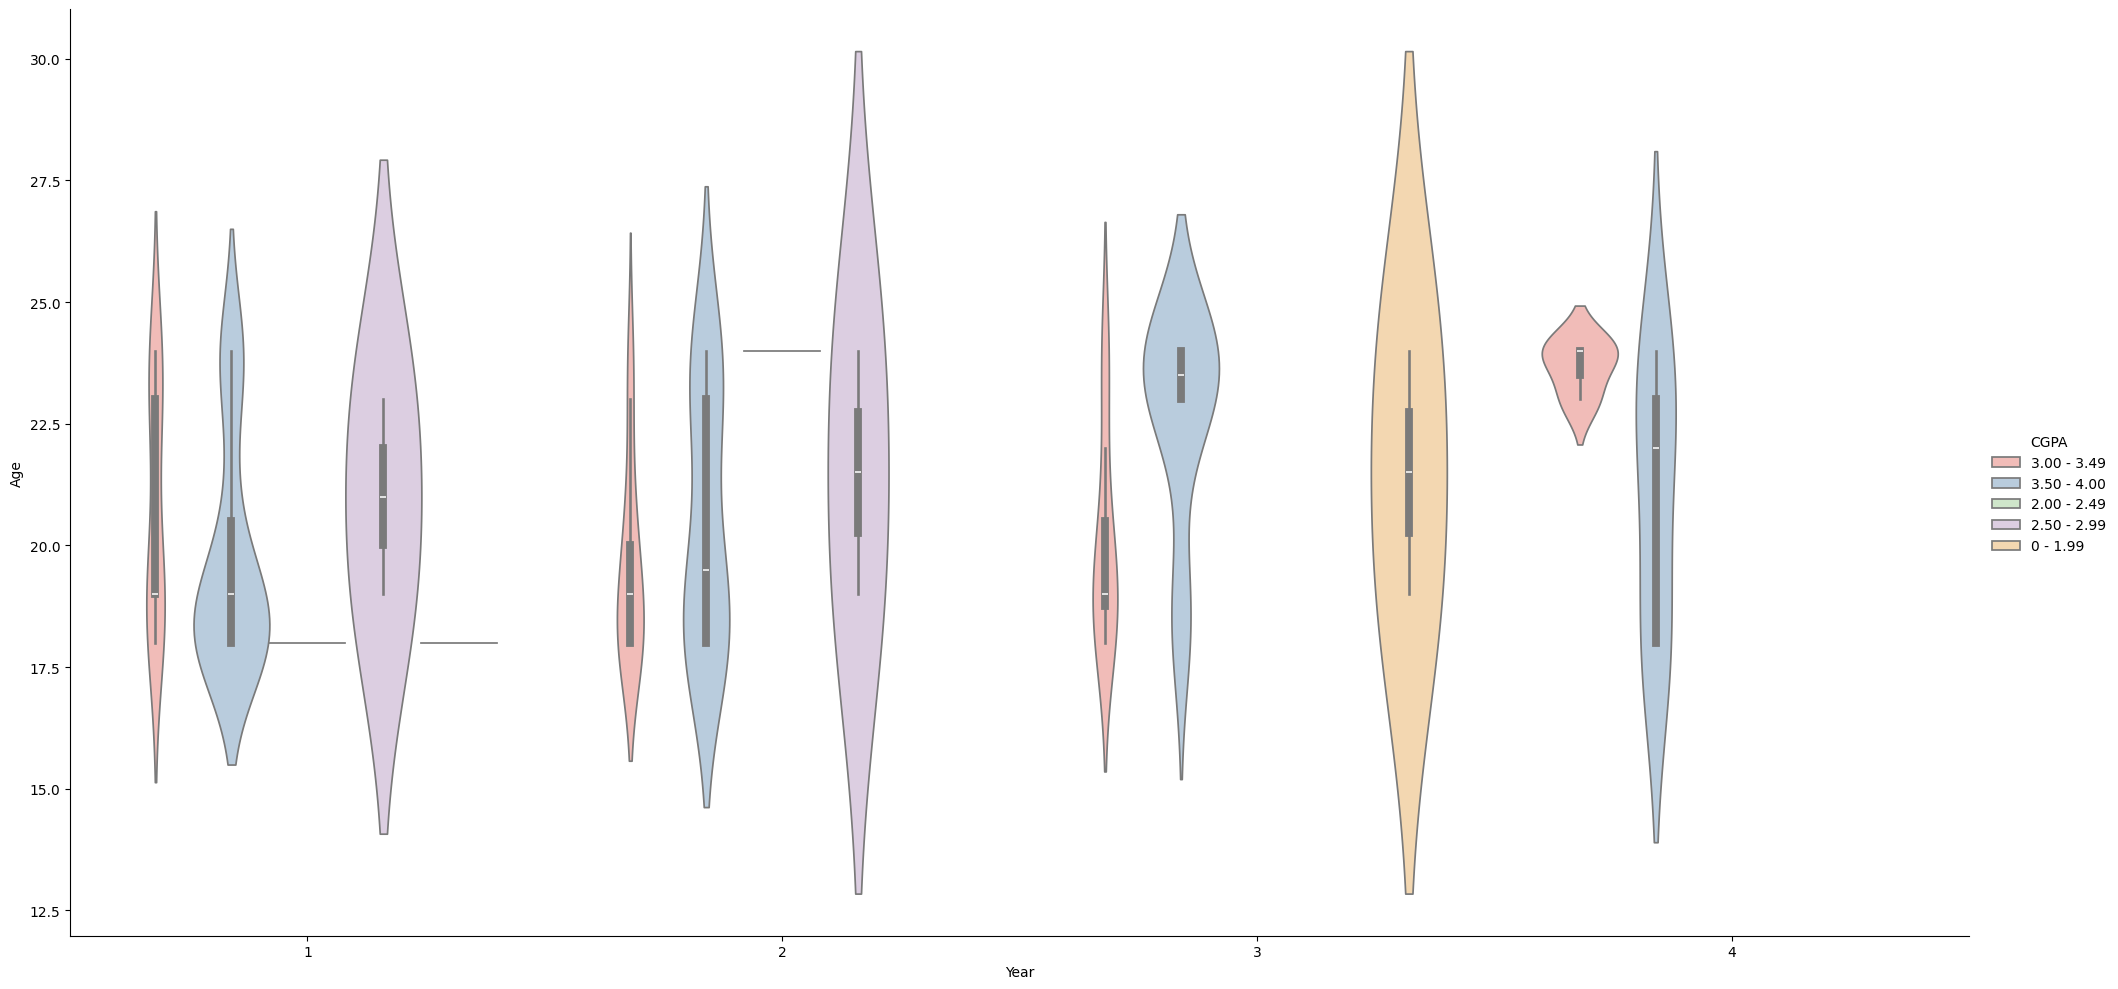

In [98]:
sns.catplot(data=data, x="Year", y="Age", hue="CGPA", kind="violin", palette="Pastel1",height=10,aspect=2)

<Axes: >

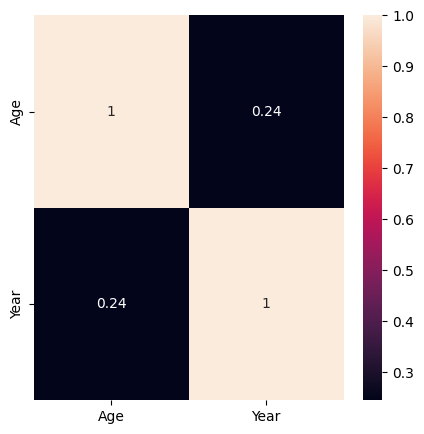

In [100]:
#correlation matrix
corrmat= data.corr(numeric_only=True)
plt.figure(figsize=(5,5))
sns.heatmap(corrmat,annot=True, cmap=None)

In [101]:
data.drop('Timestamp', axis=1, inplace=True)

In [102]:
data.head(20)

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Treatment
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic Education,2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,IT,1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Law,3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No
5,Male,19.0,Engineering,2,3.50 - 4.00,No,No,No,Yes,No
6,Female,23.0,Pendidikan Islam,2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,Female,18.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No
8,Female,19.0,Human Resources,2,2.50 - 2.99,No,No,No,No,No
9,Male,18.0,Irkhs,1,3.50 - 4.00,No,No,Yes,Yes,No


In [103]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
categorical_columns= [x for x in data.columns if data.dtypes[x] == 'object']
for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])
data.head()

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Treatment
0,0,18.0,14,1,3,0,1,0,1,0
1,1,21.0,20,2,3,0,0,1,0,0
2,1,19.0,18,1,3,0,1,1,1,0
3,0,22.0,25,3,3,1,1,0,0,0
4,1,23.0,29,4,3,0,0,0,0,0


<Axes: >

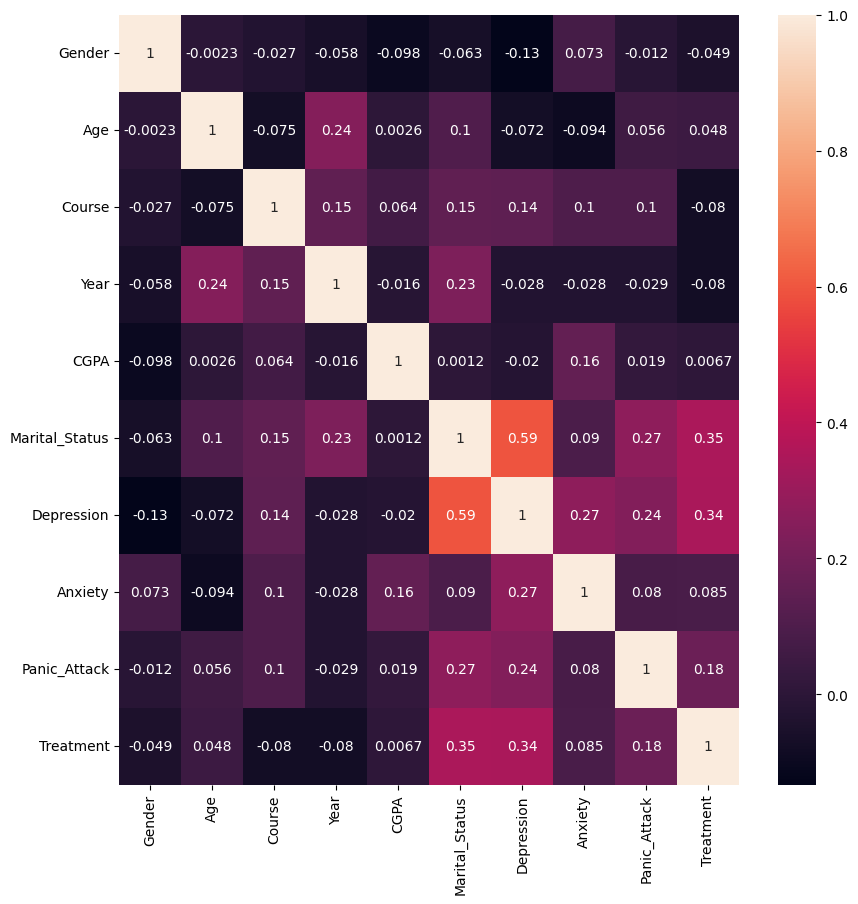

In [104]:
#correlation matrix
corrmat= data.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corrmat,annot=True, cmap=None)

In [105]:
X = data.drop(["CGPA"],axis=1)
y = data["CGPA"]

In [106]:
#spliting test and training sets
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [107]:
#A quick model selection process
#pipelines of models( it is short was to fit and pred)
pipeline_lr=Pipeline([('lr_classifier',LogisticRegression(random_state=42))])

pipeline_dt=Pipeline([ ('dt_classifier',DecisionTreeClassifier(random_state=42))])

pipeline_rf=Pipeline([('rf_classifier',RandomForestClassifier())])

pipeline_svc=Pipeline([('sv_classifier',SVC())])

# List of all the pipelines
pipelines = [pipeline_lr, pipeline_dt, pipeline_rf, pipeline_svc]

# Dictionary of pipelines and classifier types for ease of reference
pipe_dict = {0: 'Logistic Regression', 1: 'Decision Tree', 2: 'RandomForest', 3: "SVC"}


# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, y_train)

#cross validation on accuracy
cv_results_accuracy = []
for i, model in enumerate(pipelines):
    cv_score = cross_val_score(model, X_train,y_train, cv=10 )
    cv_results_accuracy.append(cv_score)
    print("%s: %f " % (pipe_dict[i], cv_score.mean()))

Logistic Regression: 0.557143 
Decision Tree: 0.471429 
RandomForest: 0.628571 
SVC: 0.500000 


In [108]:
#taking look at the test set
pred_rfc = pipeline_rf.predict(X_test)
accuracy = accuracy_score(y_test, pred_rfc)
print(accuracy)

0.5333333333333333


In [109]:
RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)
#Testing the Model on test set
predictions=RF_model.predict(X_test)
acccuracy= accuracy_score(y_test,predictions)
acccuracy

0.43333333333333335

In [110]:
acccuracy = accuracy_score(y_test, predictions)
recall = recall_score(y_test, predictions, average="weighted")
precision = precision_score(y_test, predictions, average="weighted")
f1_score = f1_score(y_test, predictions, average="micro")

print("********* Random Forest Results *********")
print("Accuracy    : ", acccuracy)
print("Recall      : ", recall)
print("Precision   : ", precision)
print("F1 Score    : ", f1_score)

********* Random Forest Results *********
Accuracy    :  0.43333333333333335
Recall      :  0.43333333333333335
Precision   :  0.36666666666666664
F1 Score    :  0.43333333333333335


In [111]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.45      0.75      0.56        12
           4       0.40      0.29      0.33        14

    accuracy                           0.43        30
   macro avg       0.17      0.21      0.18        30
weighted avg       0.37      0.43      0.38        30



<Axes: >

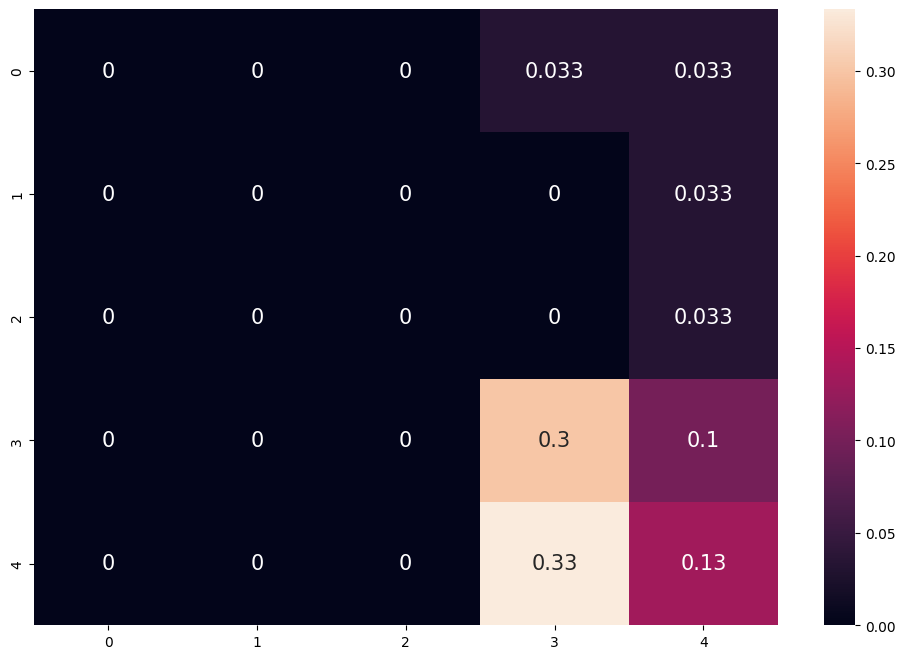

In [112]:
# confusion matrix
plt.subplots(figsize=(12,8))
cf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(cf_matrix/np.sum(cf_matrix), cmap=None,annot = True, annot_kws = {'size':15})

# Overall Analysis Notes

This notebook performs an exploratory data analysis (EDA) and builds several classification models to predict student CGPA based on various factors, including mental health indicators. The analysis proceeds through data loading, cleaning, visualization, feature engineering, and model selection/evaluation.

## 1. Data Loading and Initial Inspection

-   **Libraries Imported**: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, and various `sklearn` modules for preprocessing, model selection, and metrics.
-   **Data Source**: The dataset `Student Mental health.csv` was loaded into a pandas DataFrame named `data`.
-   **Initial Information (`data.info()`)**:
    -   Initially contained 101 entries and 11 columns.
    -   `Timestamp` (object), `Choose your gender` (object), `Age` (float64), `What is your course?` (object), `Your current year of Study` (object), `What is your CGPA?` (object), `Marital status` (object), `Do you have Depression?` (object), `Do you have Anxiety?` (object), `Do you have Panic attack?` (object), `Did you seek any specialist for a treatment?` (object).
    -   One missing value was identified in the 'Age' column.
-   **Missing Value Handling**: The row with the missing 'Age' value was dropped, reducing the dataset to 100 entries.

## 2. Data Cleaning and Preprocessing

-   **Column Renaming**: Columns were renamed for clarity and ease of use:
    -   `Choose your gender` -> `Gender`
    -   `What is your course?` -> `Course`
    -   `Your current year of Study` -> `Year`
    -   `What is your CGPA?` -> `CGPA`
    -   `Marital status` -> `Marital_Status`
    -   `Do you have Depression?` -> `Depression`
    -   `Do you have Anxiety?` -> `Anxiety`
    -   `Do you have Panic attack?` -> `Panic_Attack`
    -   `Did you seek any specialist for a treatment?` -> `Treatment`
-   **'Year' Column Cleaning**: The 'Year' column contained values like 'year 1', 'Year 1', etc. A `Clean` function was applied to extract the numerical year (e.g., '1', '2') and convert the column to `int64`. This resolved an earlier issue where the function was returning a tuple, and a subsequent `TypeError` was avoided by confirming the column type was already `int64`.
-   **'CGPA' Column Cleaning**: The 'CGPA' column contained string ranges (e.g., '3.00 - 3.49', '3.50 - 4.00 '). Extra spaces were removed using `string.strip()`.
-   **'Course' Column Cleaning**: Redundant and inconsistent course names (e.g., 'engin', 'Engine', 'BIT') were replaced with standardized names (e.g., 'Engineering', 'IT'), reducing the number of unique courses from 49 to 37.
-   **Categorical Feature Encoding**: All remaining `object` type columns (now representing categorical data) were transformed into numerical representations using `LabelEncoder` from `sklearn.preprocessing`. This includes 'Gender', 'Course', 'CGPA', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', and 'Treatment'. The `Timestamp` column was dropped before this step.

## 3. Exploratory Data Analysis (EDA) and Visualizations

-   **Pair Plot**: An initial `sns.pairplot` was generated to visualize relationships between numerical features ('Age' and 'Year').
-   **Course Distribution by Year**: Count plots were created to show the distribution of students across different courses for each year of study (Year 1, Year 2, Year 3, Year 4).
-   **Mental Health Indicators by Course and Gender**: Stripplots were used to visualize the distribution of 'Anxiety', 'Depression', and 'Panic_Attack' across different 'Course' categories, separated by 'Gender'. This helps in identifying potential gender-based patterns or course-specific prevalence.
-   **Age Distribution**: A histogram and density plot of the 'Age' column were generated to show the distribution of ages among the students.
-   **Age vs. Year with Mental Health/CGPA**: Violin plots explored the relationship between 'Age' and 'Year', colored by 'Depression', 'Anxiety', 'Panic_Attack', and 'CGPA'. These plots provide insights into how age distribution varies across years and if mental health conditions or CGPA ranges are more prevalent in certain age/year groups.

## 4. Correlation Analysis

-   **Initial Correlation Matrix**: An attempt to compute the correlation matrix initially failed due to the presence of the 'Timestamp' column, which contained non-numeric string values.
-   **Resolution**: The `data.corr()` call was modified to `data.corr(numeric_only=True)` to exclude non-numeric columns. This generated a correlation matrix and heatmap for 'Age' and 'Year'.
-   **Dropping 'Timestamp'**: The 'Timestamp' column was explicitly dropped from the DataFrame, `data.drop('Timestamp', axis=1, inplace=True)`.
-   **Final Correlation Matrix**: After all categorical features were label-encoded, a comprehensive correlation matrix and heatmap were generated, showing the relationships between all numerical features in the dataset.

## 5. Model Preparation

-   **Feature and Target Split**: The 'CGPA' column was designated as the target variable (`y`), and all other columns were used as features (`X`).
-   **Train-Test Split**: The dataset was split into training (70%) and testing (30%) sets using `train_test_split` with `random_state = 42` for reproducibility.

## 6. Model Selection (Pipeline Approach)

-   **Model Pipelines**: Pipelines were created for four different classification models:
    -   Logistic Regression (`LogisticRegression`)
    -   Decision Tree (`DecisionTreeClassifier`)
    -   Random Forest (`RandomForestClassifier`)
    -   Support Vector Classifier (`SVC`)
-   **Training and Cross-Validation**: Each pipeline was fitted to the training data (`X_train`, `y_train`). Subsequently, 10-fold cross-validation was performed on the training set to evaluate the accuracy of each model. The mean accuracy scores were printed:
    -   Logistic Regression: 0.557143
    -   Decision Tree: 0.471429
    -   RandomForest: 0.628571
    -   SVC: 0.500000
-   **Observation**: Random Forest showed the highest mean cross-validation accuracy on the training set.

## 7. Model Evaluation (Random Forest)

-   **Test Set Prediction (Pipeline RF)**: The `pipeline_rf` was used to make predictions on the `X_test` set, resulting in an accuracy of approximately 0.533.
-   **Direct Random Forest Model**: A `RandomForestClassifier` was initialized and trained directly on `X_train` and `y_train`. Predictions were then made on `X_test`.
-   **Evaluation Metrics**: The following metrics were calculated and printed for this Random Forest model's performance on the test set:
    -   Accuracy: 0.4333
    -   Recall: 0.4333
    -   Precision: 0.3667
    -   F1 Score: 0.4333
-   **Classification Report**: A detailed classification report was generated, providing precision, recall, f1-score, and support for each CGPA class. This revealed that the model struggled significantly with certain classes (e.g., classes 0, 1, 2 had 0.00 precision, recall, f1-score), performing better on classes 3 and 4.
-   **Confusion Matrix**: A confusion matrix was visualized as a heatmap, showing the proportion of actual vs. predicted classes. This visually confirmed the model's difficulty in correctly classifying instances of certain CGPA categories, particularly classes 0, 1, and 2, which were mostly misclassified into classes 3 and 4.